In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np


# Cree un dataset de 5000 requetes

In [3]:
import random
nb_datasets1 = 1000
min_size1 = 100
max_size1 = 1024

datasets_1 = [(f"ds{i}", random.randrange(min_size1,max_size1)) for i in range(nb_datasets1)]
datasets_1

[('ds0', 440),
 ('ds1', 483),
 ('ds2', 172),
 ('ds3', 201),
 ('ds4', 742),
 ('ds5', 504),
 ('ds6', 686),
 ('ds7', 148),
 ('ds8', 245),
 ('ds9', 582),
 ('ds10', 485),
 ('ds11', 278),
 ('ds12', 723),
 ('ds13', 133),
 ('ds14', 124),
 ('ds15', 983),
 ('ds16', 115),
 ('ds17', 1014),
 ('ds18', 979),
 ('ds19', 761),
 ('ds20', 136),
 ('ds21', 875),
 ('ds22', 709),
 ('ds23', 315),
 ('ds24', 363),
 ('ds25', 838),
 ('ds26', 795),
 ('ds27', 691),
 ('ds28', 215),
 ('ds29', 378),
 ('ds30', 743),
 ('ds31', 475),
 ('ds32', 603),
 ('ds33', 914),
 ('ds34', 243),
 ('ds35', 688),
 ('ds36', 131),
 ('ds37', 779),
 ('ds38', 539),
 ('ds39', 499),
 ('ds40', 649),
 ('ds41', 330),
 ('ds42', 532),
 ('ds43', 346),
 ('ds44', 925),
 ('ds45', 884),
 ('ds46', 678),
 ('ds47', 254),
 ('ds48', 524),
 ('ds49', 232),
 ('ds50', 779),
 ('ds51', 151),
 ('ds52', 430),
 ('ds53', 701),
 ('ds54', 338),
 ('ds55', 248),
 ('ds56', 105),
 ('ds57', 923),
 ('ds58', 869),
 ('ds59', 140),
 ('ds60', 1017),
 ('ds61', 210),
 ('ds62', 1015),

In [4]:
len(datasets_1)

1000

In [5]:
sum = 0 
for item in datasets_1:
    sum += item[1]
sum/1024

552.39453125

In [6]:
traces = pd.read_csv("tracesV4_without_node_dataset.csv")
traces.head()

,id_task,application_type,creation_date,completion_date,time_compute (s),time_env (s),time_dl (s),time_up (s),mobo_uuid,qrad_uuid,qbox_uuid,cpu_name,nb_cores,status
0,12,3DRender,2021-01-26 23:21:37,2021-01-26 23:23:19,0,91,2,0,4F424F4D-ADF0-084E-AC68-00D861156ABF,44415251-ADF0-084E-AC68-000000000000,584f4251-4000-0000-1001-000000000004,AMD Ryzen 7 2700X Eight-Core Processor,8,Preempted
1,13,3DRender,2021-01-26 23:21:37,2021-01-26 23:23:19,0,91,2,0,4F424F4D-ADF0-084E-AC68-00D8611555D3,44415251-ADF0-084E-AC68-000000000000,584f4251-4000-0000-1001-000000000004,AMD Ryzen 7 2700X Eight-Core Processor,8,Preempted
2,14,3DRender,2021-01-26 23:21:37,2021-01-26 23:24:29,103,63,4,1,4F424F4D-58D8-00D7-B155-00D8617B5DDC,44415251-58D8-00D7-B155-000000000000,584f4251-2001-0000-0000-000000000002,AMD Ryzen 7 2700 Eight-Core Processor,8,Completed
3,20,3DRender,2021-01-26 23:21:37,2021-01-26 23:24:46,121,61,4,1,4F424F4D-58D8-01D7-3AB5-00D861C8FAE7,44415251-58D8-01D7-3AB5-000000000000,584f4251-3000-0000-2000-000000000002,AMD Ryzen 7 2700 Eight-Core Processor,8,Completed
4,21,3DRender,2021-01-26 23:21:37,2021-01-26 23:24:46,122,61,4,1,4F424F4D-58D8-01D7-3AB5-00D861C8FC14,44415251-58D8-01D7-3AB5-000000000000,584f4251-3000-0000-2000-000000000002,AMD Ryzen 7 2700 Eight-Core Processor,8,Completed


In [7]:
requests = traces.sample(n=10000)
#requests.to_csv('dataset_5000.csv', index=False)

In [9]:
a = 1.25
zipf_indices_1 = np.random.zipf(a, requests.shape[0])

# Ensure indices are within the range of the elements list
zipf_indices_1 = [i % len(datasets_1) for i in zipf_indices_1]

# Map the indices to elements in the list
requests["dataset"] = [datasets_1[i][0] for i in zipf_indices_1]
requests["dataset_size"] = [datasets_1[i][1] for i in zipf_indices_1]
#tracesV1 = pd.concat([df_sans_general, df], axis=1, ignore_index=True)
x,y = np.unique(zipf_indices_1, return_counts=True)
print(max(y))
for i in range(len(x)):
    print(x[i], y[i])

2137
0 1
1 2137
2 902
3 505
4 393
5 307
6 239
7 197
8 168
9 158
10 126
11 99
12 93
13 84
14 97
15 72
16 74
17 64
18 58
19 44
20 56
21 51
22 39
23 57
24 51
25 39
26 47
27 45
28 39
29 32
30 33
31 39
32 34
33 33
34 26
35 36
36 18
37 24
38 26
39 29
40 25
41 31
42 11
43 25
44 30
45 21
46 20
47 18
48 15
49 14
50 16
51 17
52 14
53 15
54 14
55 15
56 17
57 19
58 14
59 10
60 14
61 12
62 12
63 9
64 14
65 18
66 8
67 9
68 14
69 10
70 14
71 18
72 11
73 20
74 7
75 9
76 8
77 11
78 9
79 9
80 12
81 13
82 8
83 9
84 7
85 9
86 14
87 8
88 10
89 8
90 7
91 9
92 12
93 10
94 11
95 7
96 11
97 8
98 3
99 10
100 6
101 7
102 16
103 5
104 9
105 5
106 14
107 6
108 9
109 8
110 5
111 12
112 11
113 8
114 6
115 11
116 10
117 6
118 6
119 7
120 7
121 14
122 6
123 7
124 8
125 6
126 8
127 8
128 10
129 8
130 8
131 8
132 8
133 6
134 9
135 6
136 6
137 9
138 6
139 4
140 6
141 7
142 4
143 3
144 4
145 8
146 2
147 4
148 1
149 7
150 3
151 6
152 4
153 9
154 4
155 13
156 7
157 8
158 8
159 8
160 9
161 13
162 5
163 5
164 6
165 3
166 3
16

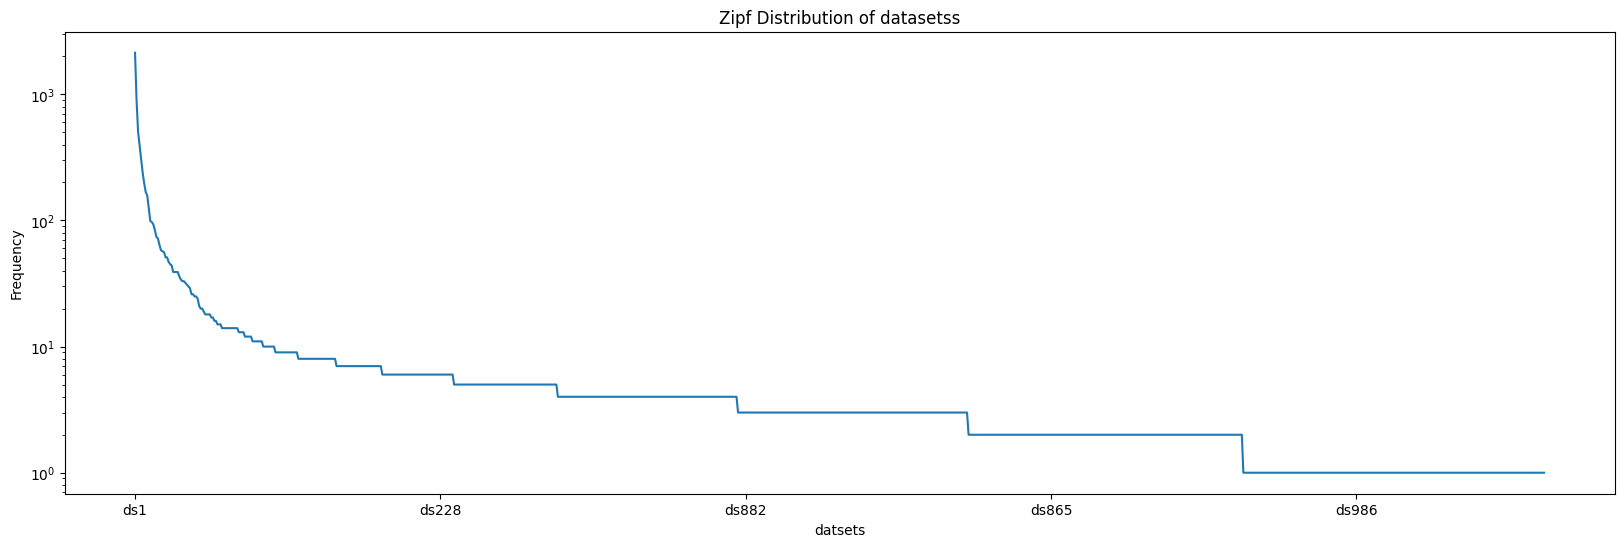

In [12]:
import matplotlib.pyplot as plt
element_counts = pd.Series(requests["dataset"]).value_counts()
element_counts.plot(kind='line', logy=True, figsize=(20, 6), title='Zipf Distribution of datasetss')
plt.xlabel('datsets')
plt.ylabel('Frequency')
plt.show()

In [9]:
nb_node = 8

requests['node_id'] = np.random.randint(0, nb_node, requests.shape[0])
requests.head()

,id_task,application_type,creation_date,completion_date,time_compute (s),time_env (s),time_dl (s),time_up (s),mobo_uuid,qrad_uuid,qbox_uuid,cpu_name,nb_cores,status,dataset,dataset_size,node_id
28129,120403,Risk,2021-02-27 13:44:55,2021-03-01 13:47:59,172881,92,10,0,4F424F4D-58D8-00D7-B137-00D861156A01,44415251-58D8-00D7-B137-000000000000,584f4251-4000-0000-1001-000000000005,AMD Ryzen 7 2700X Eight-Core Processor,8,Preempted,ds145,283,1
500281,2209607,Risk,2022-03-18 11:50:13,2022-03-18 11:52:39,0,140,1,1,4F424F4D-58D8-00D7-B08F-00D8611556B1,44415251-58D8-00D7-B08F-000000000000,584f4251-4000-0000-1001-000000000001,AMD Ryzen 7 2700X Eight-Core Processor,8,Preempted,ds1,681,4
335159,1341860,3DRender,2021-10-17 22:11:23,2021-10-17 22:22:09,644,1,1,2,4F424F4D-58D8-00D7-A5E8-00D8619C7688,44415251-58D8-00D7-A5E8-000000000000,584f4251-4000-0000-1000-000000000019,AMD Ryzen 7 2700X Eight-Core Processor,8,Completed,ds6,846,2
36981,138150,3DRender,2021-03-07 23:10:05,2021-03-07 23:17:31,350,94,1,1,4F424F4D-58D8-00D7-A615-00D8619C74AB,44415251-58D8-00D7-A615-000000000000,584f4251-4000-0000-1000-000000000015,AMD Ryzen 7 2700X Eight-Core Processor,8,Failed,ds53,968,4
339707,1357621,Risk,2021-10-20 20:07:23,2021-10-20 20:13:31,77,97,1,2,4F424F4D-58D8-01D7-3863-00D8611556E4,44415251-58D8-01D7-3863-000000000000,584f4251-4000-0000-1001-000000000003,AMD Ryzen 7 2700X Eight-Core Processor,8,Preempted,ds9,466,7


In [10]:
requests.to_csv("../random_subset.csv", index=False)

In [15]:
import pandas as pd
d = pd.read_csv('../random_subset.csv')

datasets_1 = []
ids = []
sizes = []
for i, row in d.iterrows():
    if row['dataset'] not in ids:
        ids.append(row['dataset'])
        datasets_1.append((row['dataset'],int(row['dataset_size'])))
        sizes.append(int(row['dataset_size']))
x = ["ds461","ds69","ds345","ds228","ds389","ds711","ds655","ds186","ds356","ds695","ds930","ds45","ds236","ds380","ds11","ds237","ds506","ds49","ds204","ds161","ds125","ds142","ds195","ds358","ds566","ds622","ds911","ds28","ds551","ds580","ds605","ds545","ds929","ds273","ds653","ds50","ds888","ds285","ds103","ds2","ds967","ds4","ds516","ds409","ds504","ds95","ds752","ds895"]
summe = 0
#for d in x:
for s in datasets_1:
    summe += s[1]
print(len(ids))


920


In [18]:
import numpy as np

unique, count = np.unique(d['dataset'], return_counts=True)
print(unique)

['ds0' 'ds1' 'ds10' 'ds100' 'ds101' 'ds102' 'ds103' 'ds104' 'ds105'
 'ds106' 'ds107' 'ds108' 'ds109' 'ds11' 'ds110' 'ds111' 'ds112' 'ds113'
 'ds114' 'ds115' 'ds116' 'ds117' 'ds118' 'ds119' 'ds12' 'ds120' 'ds121'
 'ds122' 'ds123' 'ds124' 'ds125' 'ds126' 'ds127' 'ds128' 'ds129' 'ds13'
 'ds130' 'ds131' 'ds132' 'ds133' 'ds134' 'ds135' 'ds136' 'ds137' 'ds138'
 'ds139' 'ds14' 'ds140' 'ds141' 'ds142' 'ds143' 'ds144' 'ds145' 'ds146'
 'ds147' 'ds148' 'ds149' 'ds15' 'ds150' 'ds151' 'ds152' 'ds153' 'ds154'
 'ds155' 'ds157' 'ds158' 'ds159' 'ds16' 'ds160' 'ds161' 'ds162' 'ds163'
 'ds164' 'ds165' 'ds166' 'ds167' 'ds168' 'ds169' 'ds17' 'ds170' 'ds171'
 'ds172' 'ds173' 'ds174' 'ds175' 'ds176' 'ds177' 'ds178' 'ds18' 'ds180'
 'ds181' 'ds182' 'ds183' 'ds184' 'ds185' 'ds186' 'ds187' 'ds188' 'ds189'
 'ds19' 'ds190' 'ds191' 'ds192' 'ds193' 'ds194' 'ds195' 'ds196' 'ds197'
 'ds198' 'ds199' 'ds2' 'ds20' 'ds200' 'ds201' 'ds202' 'ds203' 'ds204'
 'ds205' 'ds206' 'ds207' 'ds208' 'ds209' 'ds21' 'ds210' 'ds211' 'ds2

In [21]:
popularities = {}
for i, ds in enumerate(unique):
    popularities[ds] = int(count[i])

popularities['ds15']

70

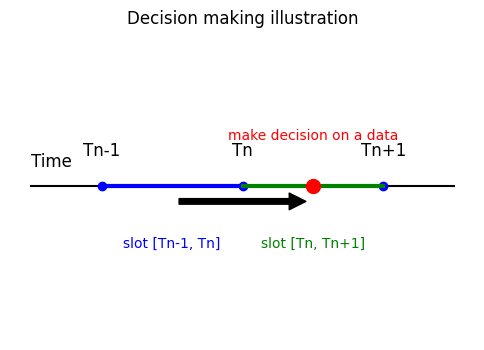

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Création de la figure et de l'axe
fig, ax = plt.subplots(figsize=(6, 4))

# Définition des positions sur l'axe du temps
Tn_minus_1 = 1
Tn = 3
Tn_plus_1 = 5

# Tracé de l'axe du temps
ax.plot([Tn_minus_1-1, Tn_plus_1+1], [1, 1], color='black')
ax.text(Tn_minus_1-1, 1.05, "Time", fontsize=12, verticalalignment='bottom')

# Points Tn-1, Tn et Tn+1
ax.plot([Tn_minus_1, Tn, Tn_plus_1], [1, 1, 1], 'bo')
ax.text(Tn_minus_1, 1.1, "Tn-1", fontsize=12, horizontalalignment='center')
ax.text(Tn, 1.1, "Tn", fontsize=12, horizontalalignment='center')
ax.text(Tn_plus_1, 1.1, "Tn+1", fontsize=12, horizontalalignment='center')

# Dessiner les intervalles de temps
ax.plot([Tn_minus_1, Tn], [1, 1], color='blue', linewidth=3)
ax.plot([Tn, Tn_plus_1], [1, 1], color='green', linewidth=3)

# Ajouter des annotations pour les intervalles
ax.text((Tn_minus_1+Tn)/2, 0.8, "slot [Tn-1, Tn]", fontsize=10, color='blue', horizontalalignment='center')
ax.text((Tn+Tn_plus_1)/2, 0.8, "slot [Tn, Tn+1]", fontsize=10, color='green', horizontalalignment='center')

# Représentation de la donnée à supprimer
ax.plot((Tn+Tn_plus_1)/2, 1, 'ro', markersize=10)
ax.text((Tn+Tn_plus_1)/2, 1.15, "make decision on a data", fontsize=10, color='red', horizontalalignment='center')

# Flèche de vérification vers l'intervalle Tn-1 à Tn
ax.annotate('', xy=((Tn+Tn_plus_1)/2, 0.95), xytext=((Tn_minus_1+Tn)/2, 0.95),
            arrowprops=dict(facecolor='black', shrink=0.05))

# Annotation de la vérification
#ax.text((Tn+Tn_minus_1)/2, 0.65, "Vérifier si utilisée", fontsize=10, horizontalalignment='center')

# Ajustements finaux
ax.set_ylim(0.5, 1.5)
ax.set_axis_off()  # On cache les axes

plt.title("Decision making illustration")
plt.show()
